Train Accuracy: 0.9083792530394472
Test Accuracy : 0.9005510364733665

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.94      6673
           1       0.61      0.55      0.58       949

    accuracy                           0.90      7622
   macro avg       0.77      0.75      0.76      7622
weighted avg       0.90      0.90      0.90      7622



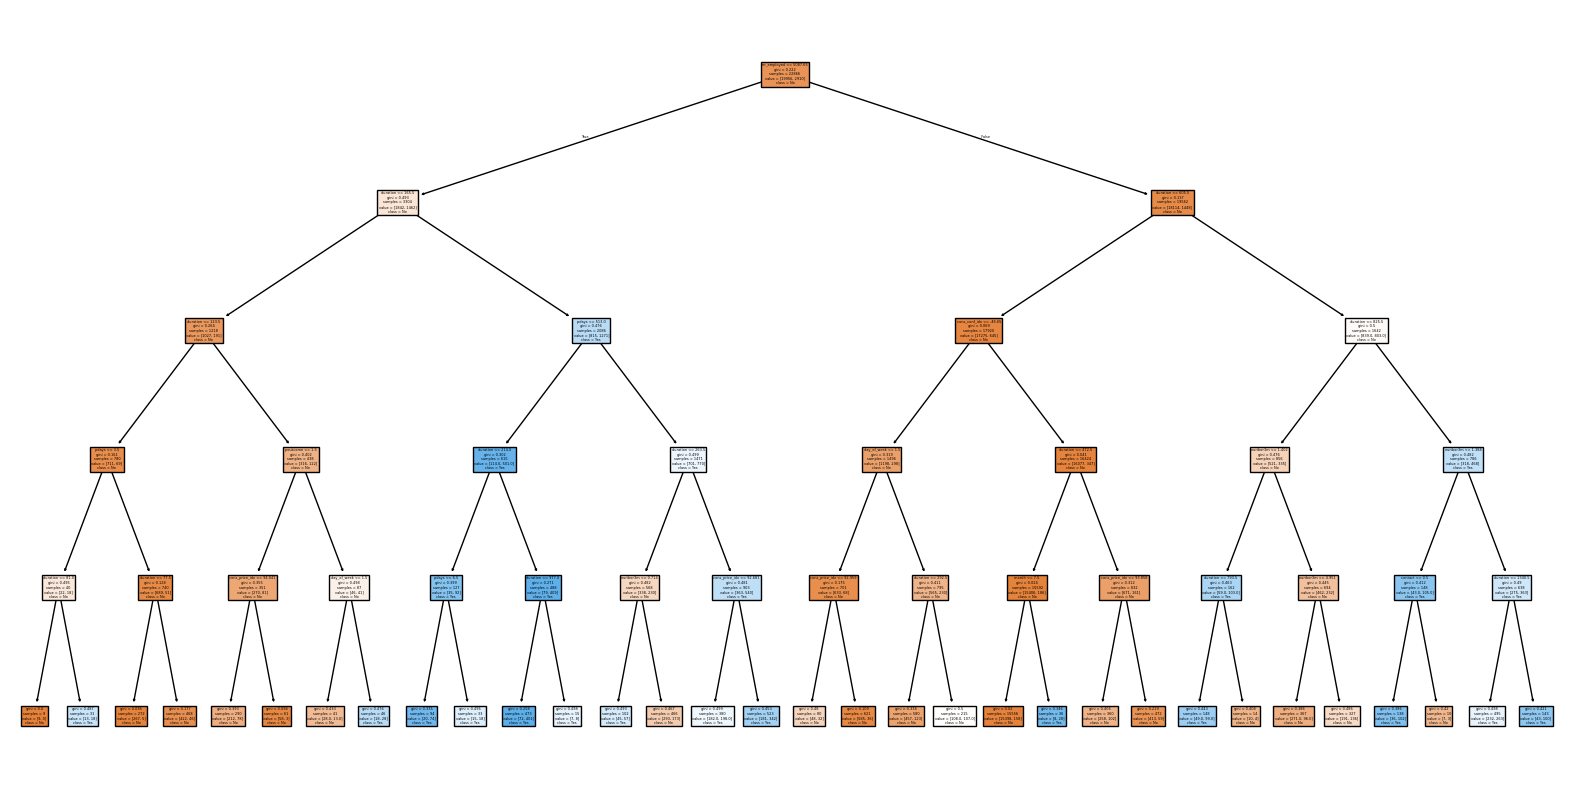

In [6]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# 2. Load Dataset
# Please upload the 'bank.csv' file to your Colab environment or provide the correct path.
df = pd.read_csv("/content/banking.csv", sep=',')

# 3. Handle "unknown" values
df.replace("unknown", pd.NA, inplace=True)
df.dropna(inplace=True)

# 4. Encode Categorical Features
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# 5. Split Features & Target
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 6. Train Decision Tree Model
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)

# 7. Prediction & Evaluation
y_pred = model.predict(X_test)

print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8. Visualize Decision Tree
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True
)
plt.show()